# 1. 读取固定配方的测试数据

本轮用CID4471和CID4535构建参考，CID4067提供测试细胞。按CAF和CD8的0、1、3个细胞组合构造10细胞混合，每个组合含1个PVL、1个背景类型，其余为癌上皮。背景类型轮换CD4、髓系、内皮、B、NK、NKT和Cycling T，每种配方重复3次。

另对测试供者中存在的11类分别构造5细胞纯群，每类重复5次。244个基础混合分别保留原计数和25%抽稀计数，共488个spot。同一spot内细胞不重复，不同spot之间可以重复使用测试细胞，两个深度版本共享来源细胞。

先执行build_known_composition.py和run_known_composition_rctd.R，下面从保存的输入计算NNLS，并读取RCTD预测。

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import anndata as ad
from scipy.optimize import nnls
import matplotlib.pyplot as plt
from IPython.display import display

project_dir = Path("/Users/georicl/Documents/sc_sncell_github")
input_dir = project_dir / "data/processed/Wu2021_known_composition_v1"
result_dir = project_dir / "results/Wu2021_known_composition_v1"
protocol = json.loads((result_dir / "protocol.json").read_text())
design = pd.read_csv(result_dir / "simulation_design.csv", index_col=0)
truth_rna = pd.read_csv(result_dir / "truth_rna_fraction.csv", index_col=0)
truth_cells = pd.read_csv(result_dir / "truth_cell_fraction.csv", index_col=0)
spots = ad.read_h5ad(input_dir / "simulated_spots.h5ad")
profiles = pd.read_csv(input_dir / "nnls_reference_profiles.csv", index_col=0)
assert design.index.equals(spots.obs_names)
assert truth_rna.index.equals(design.index)
assert truth_cells.index.equals(design.index)
display(design.groupby(["scenario", "depth_fraction"]).agg(
    n_spots=("n_cells", "size"), cells_per_spot=("n_cells", "first"),
    umi_min=("nUMI", "min"), umi_median=("nUMI", "median"), umi_max=("nUMI", "max")
))


n_spots  cells_per_spot  umi_min  umi_median  \
scenario  depth_fraction                                                 
factorial 0.25                189              10     3845      9060.0   
          1.00                189              10    15987     36382.0   
pure      0.25                 55               5      874      1953.0   
          1.00                 55               5     3546      7852.0   

                          umi_max  
scenario  depth_fraction           
factorial 0.25              21924  
          1.00              87129  
pure      0.25               8029  
          1.00              32188

# 2. 使用NNLS计算简单基线

参考表达特征按每个参考细胞的全库UMI归一化，再按类型取平均。基因按参考类型间方差/平均值排序，取前2000个；基因选择使用参考侧数据。

NNLS求解非负系数，再除以系数之和得到相对权重。RCTD按自己的流程进行基因筛选和平台校正，两个方法都使用同一供者划分及模拟计数。

In [2]:
started = time.time()
signature = profiles.to_numpy()
expression = spots[:, profiles.index].X.toarray() / design.nUMI.to_numpy()[:, None]
coefficients = np.vstack([nnls(signature, row)[0] for row in expression])
assert np.isfinite(coefficients).all() and (coefficients >= 0).all()
assert (coefficients.sum(axis=1) > 0).all()
nnls_weights = pd.DataFrame(
    coefficients / coefficients.sum(axis=1, keepdims=True),
    index=design.index, columns=profiles.columns
)
nnls_weights.to_csv(result_dir / "nnls_relative_weights.csv")
pd.DataFrame(coefficients, index=design.index, columns=profiles.columns).to_csv(
    result_dir / "nnls_raw_coefficients.csv"
)
print("NNLS耗时（秒）：", round(time.time() - started, 2))


NNLS耗时（秒）： 0.15


# 3. 对齐预测和已知组成

每个spot保存两份组成。RNA份额按抽稀后各类细胞实际贡献的UMI计算，细胞份额按混入的细胞个数计算。先按条码和标签对齐，再分别评价这两种量。

RCTD的原始权重保留在单独文件中，这里读取按spot总和归一化后的相对权重。

In [3]:
rctd_weights = pd.read_csv(result_dir / "rctd_relative_weights.csv", index_col=0)
predictions = {"RCTD": rctd_weights, "NNLS": nnls_weights}
for name, frame in predictions.items():
    assert frame.index.is_unique and frame.columns.is_unique
    assert set(frame.index) == set(design.index)
    assert set(frame.columns) == set(truth_rna.columns)
    frame = frame.loc[design.index, truth_rna.columns]
    assert np.isfinite(frame.to_numpy()).all() and (frame.to_numpy() >= 0).all()
    assert np.allclose(frame.sum(axis=1), 1)
    predictions[name] = frame

types = truth_rna.columns.tolist()
targets = ["CAFs", "T cells CD8+", "PVL", "Cancer Epithelial"]
display(truth_rna.head())
display(truth_cells.head())


,B-cells,CAFs,Cancer Epithelial,Cycling T-cells,Endothelial,Myeloid,NK cells,NKT cells,Normal Epithelial,PVL,Plasmablasts,T cells CD4+,T cells CD8+
spot_id,,,,,,,,,,,,,
mix_0000_depth100,0.0,0.0,0.949890,0.0,0.0,0.0,0.0,0.0,0.0,0.029229,0.0,0.020881,0.0
mix_0000_depth25,0.0,0.0,0.951214,0.0,0.0,0.0,0.0,0.0,0.0,0.026884,0.0,0.021902,0.0
mix_0001_depth100,0.0,0.0,0.979969,0.0,0.0,0.0,0.0,0.0,0.0,0.008879,0.0,0.011152,0.0
mix_0001_depth25,0.0,0.0,0.981248,0.0,0.0,0.0,0.0,0.0,0.0,0.008353,0.0,0.010399,0.0
mix_0002_depth100,0.0,0.0,0.904202,0.0,0.0,0.0,0.0,0.0,0.0,0.074671,0.0,0.021127,0.0


,B-cells,CAFs,Cancer Epithelial,Cycling T-cells,Endothelial,Myeloid,NK cells,NKT cells,Normal Epithelial,PVL,Plasmablasts,T cells CD4+,T cells CD8+
spot_id,,,,,,,,,,,,,
mix_0000_depth100,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0
mix_0000_depth25,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0
mix_0001_depth100,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0
mix_0001_depth25,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0
mix_0002_depth100,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.0


# 4. 按配方和深度比较误差

对混合spot和纯群分别计算每类的MAE、RMSE和平均偏移，单位为百分点。主要查看RNA份额误差，细胞份额另行列出。

有目标细胞的spot单独计算MAE；目标类型缺失的spot记录预测均值，以及权重达到1%的比例。1%是本轮提前保存的诊断阈值。

In [4]:
metric_rows = []
for method, prediction in predictions.items():
    for truth_name, truth in [("rna", truth_rna), ("cells", truth_cells)]:
        for (scenario, depth), group in design.groupby(["scenario", "depth_fraction"]):
            ids = group.index
            for cell_type in types:
                observed = truth.loc[ids, cell_type].to_numpy()
                predicted = prediction.loc[ids, cell_type].to_numpy()
                error = predicted - observed
                present = truth_cells.loc[ids, cell_type].to_numpy() > 0
                absent = ~present
                metric_rows.append({
                    "method": method, "truth": truth_name, "scenario": scenario,
                    "depth_fraction": depth, "cell_type": cell_type, "n_spots": len(ids),
                    "mae_pp": np.abs(error).mean() * 100,
                    "rmse_pp": np.sqrt(np.square(error).mean()) * 100,
                    "bias_pp": error.mean() * 100,
                    "present_mae_pp": np.abs(error[present]).mean() * 100 if present.any() else np.nan,
                    "n_present": int(present.sum()), "n_absent": int(absent.sum()),
                    "absent_mean_prediction_pct": predicted[absent].mean() * 100 if absent.any() else np.nan,
                    "absent_ge1pct_fraction": (predicted[absent] >= 0.01).mean() if absent.any() else np.nan,
                })
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(result_dir / "benchmark_metrics.csv", index=False)
main = metrics[metrics.truth.eq("rna") & metrics.scenario.eq("factorial") & metrics.cell_type.isin(targets)]
display(main[["method", "depth_fraction", "cell_type", "mae_pp", "present_mae_pp",
              "bias_pp", "absent_mean_prediction_pct", "absent_ge1pct_fraction"]].round(3))

# 保留逐spot误差，后续可以追溯到混合细胞
error_rows = []
for method, prediction in predictions.items():
    for cell_type in types:
        frame = design.copy()
        frame["cell_type"] = cell_type
        frame["method"] = method
        frame["truth_rna"] = truth_rna[cell_type]
        frame["truth_cells"] = truth_cells[cell_type]
        frame["prediction"] = prediction[cell_type]
        frame["rna_error_pp"] = (prediction[cell_type] - truth_rna[cell_type]) * 100
        error_rows.append(frame)
pd.concat(error_rows).to_csv(result_dir / "spot_prediction_errors.csv", index_label="spot_id")


,method,depth_fraction,cell_type,mae_pp,present_mae_pp,bias_pp,absent_mean_prediction_pct,absent_ge1pct_fraction
1,RCTD,0.25,CAFs,3.469,5.179,-3.218,0.050,0.000
2,RCTD,0.25,Cancer Epithelial,32.465,32.465,-32.465,NaN,NaN
9,RCTD,0.25,PVL,3.340,3.340,-3.147,NaN,NaN
12,RCTD,0.25,T cells CD8+,1.962,2.886,-1.197,0.114,0.063
14,RCTD,1.00,CAFs,3.601,5.383,-3.248,0.036,0.000
15,RCTD,1.00,Cancer Epithelial,31.394,31.394,-31.394,NaN,NaN
22,RCTD,1.00,PVL,3.489,3.489,-3.382,NaN,NaN
25,RCTD,1.00,T cells CD8+,1.731,2.536,-1.117,0.120,0.048
105,NNLS,0.25,CAFs,4.321,5.802,1.966,1.359,0.302
106,NNLS,0.25,Cancer Epithelial,42.774,42.774,-42.774,NaN,NaN


# 5. 绘制CAF和CD8的预测对照

横轴为实际RNA份额，纵轴为预测相对权重。实线表示两者相等。不同深度分别作图，查看小比例和零值位置的预测情况。

每个点是一个模拟spot，同一测试供者的细胞在不同配方中会重复使用。

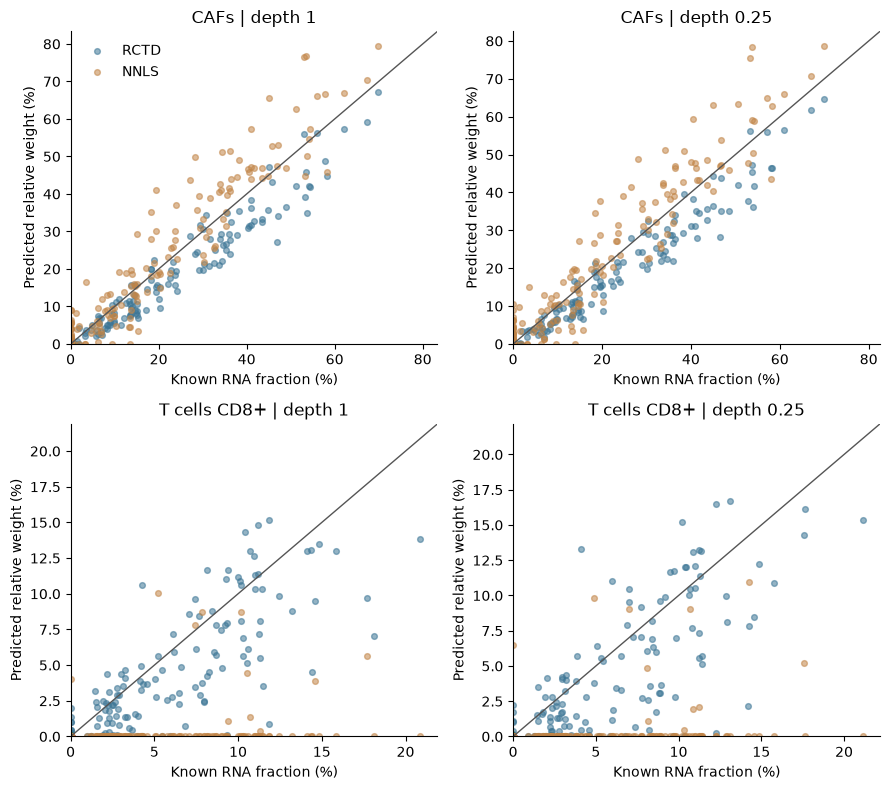

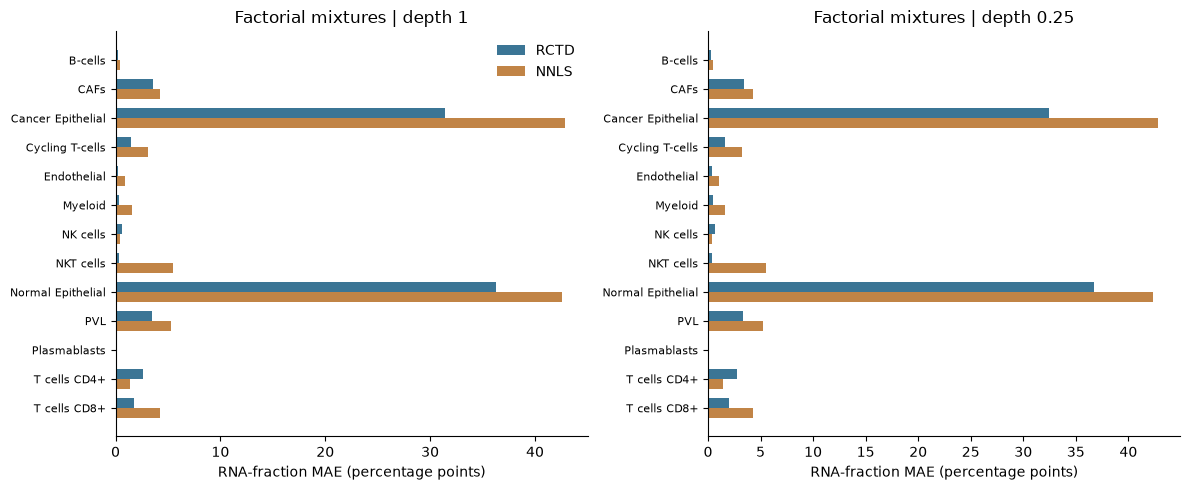

In [5]:
colors = {"RCTD": "#3b7595", "NNLS": "#c18446"}
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for i, target in enumerate(["CAFs", "T cells CD8+"]):
    for j, depth in enumerate([1.0, 0.25]):
        ax = axes[i, j]
        ids = design.index[design.scenario.eq("factorial") & design.depth_fraction.eq(depth)]
        for method, frame in predictions.items():
            ax.scatter(truth_rna.loc[ids, target] * 100, frame.loc[ids, target] * 100,
                       s=17, alpha=0.55, color=colors[method], label=method)
        upper = max(truth_rna.loc[ids, target].max(),
                    max(frame.loc[ids, target].max() for frame in predictions.values())) * 100 * 1.05
        ax.plot([0, upper], [0, upper], color="#555555", lw=1)
        ax.set_xlim(0, upper); ax.set_ylim(0, upper)
        ax.set_xlabel("Known RNA fraction (%)")
        ax.set_ylabel("Predicted relative weight (%)")
        ax.set_title(f"{target} | depth {depth:g}")
        ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].legend(frameon=False)
fig.tight_layout()
fig.savefig(result_dir / "caf_cd8_prediction_scatter.png", dpi=300)
fig.savefig(result_dir / "caf_cd8_prediction_scatter.pdf")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, depth in zip(axes, [1.0, 0.25]):
    table = metrics[
        metrics.truth.eq("rna") & metrics.scenario.eq("factorial")
        & metrics.depth_fraction.eq(depth)
    ].pivot(index="cell_type", columns="method", values="mae_pp").reindex(types)
    y = np.arange(len(types))
    ax.barh(y - 0.18, table["RCTD"], height=0.35, color=colors["RCTD"], label="RCTD")
    ax.barh(y + 0.18, table["NNLS"], height=0.35, color=colors["NNLS"], label="NNLS")
    ax.set_yticks(y, types, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("RNA-fraction MAE (percentage points)")
    ax.set_title(f"Factorial mixtures | depth {depth:g}")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig(result_dir / "all_type_mae.png", dpi=300)
fig.savefig(result_dir / "all_type_mae.pdf")
plt.show()


# 6. 查看纯群对照和缺失类型

纯群对照检查预测权重最高的类型是否对应混入的类型，并保存完整预测分布。CID4067没有正常上皮和浆母细胞，这两类在本轮的真值均为零，可以查看模型分配给它们的权重。

In [6]:
pure_rows = []
for method, prediction in predictions.items():
    for depth in [1.0, 0.25]:
        ids = design.index[design.scenario.eq("pure") & design.depth_fraction.eq(depth)]
        actual = truth_cells.loc[ids].idxmax(axis=1)
        predicted = prediction.loc[ids].idxmax(axis=1)
        for cell_type in sorted(actual.unique()):
            mask = actual.eq(cell_type)
            pure_rows.append({
                "method": method, "depth_fraction": depth, "cell_type": cell_type,
                "n_spots": int(mask.sum()),
                "dominant_type_matches": int(predicted[mask].eq(cell_type).sum()),
                "mean_weight_on_true_type": float(prediction.loc[actual.index[mask], cell_type].mean()),
            })
pure_summary = pd.DataFrame(pure_rows)
pure_summary.to_csv(result_dir / "pure_control_summary.csv", index=False)
display(pure_summary)
display(metrics[
    metrics.truth.eq("rna") & metrics.scenario.eq("factorial")
    & metrics.cell_type.isin(["Normal Epithelial", "Plasmablasts"])
][["method", "depth_fraction", "cell_type", "absent_mean_prediction_pct", "absent_ge1pct_fraction"]])


,method,depth_fraction,cell_type,n_spots,dominant_type_matches,mean_weight_on_true_type
0,RCTD,1.00,B-cells,5,5,0.986208
1,RCTD,1.00,CAFs,5,5,0.972873
2,RCTD,1.00,Cancer Epithelial,5,5,0.566753
3,RCTD,1.00,Cycling T-cells,5,0,0.214576
4,RCTD,1.00,Endothelial,5,5,0.975570
5,RCTD,1.00,Myeloid,5,5,0.995316
6,RCTD,1.00,NK cells,5,5,0.824381
7,RCTD,1.00,NKT cells,5,5,0.637227
8,RCTD,1.00,PVL,5,5,0.777807
9,RCTD,1.00,T cells CD4+,5,1,0.519797


,method,depth_fraction,cell_type,absent_mean_prediction_pct,absent_ge1pct_fraction
8,RCTD,0.25,Normal Epithelial,36.757269,0.994709
10,RCTD,0.25,Plasmablasts,0.062169,0.000000
21,RCTD,1.00,Normal Epithelial,36.323792,0.994709
23,RCTD,1.00,Plasmablasts,0.022451,0.000000
112,NNLS,0.25,Normal Epithelial,42.340582,0.931217
114,NNLS,0.25,Plasmablasts,0.000000,0.000000
125,NNLS,1.00,Normal Epithelial,42.568396,0.936508
127,NNLS,1.00,Plasmablasts,0.000000,0.000000


# 7. 查看上皮类型的分配

正常上皮在全部测试配方中均为零，但两种方法仍给出了较高权重。先查看纯癌上皮的预测，再将癌上皮与正常上皮权重相加，检查上皮总量的误差。相加后的指标是看到类型混淆后增加的诊断，不替代原定13类评价，也不改变模型拟合。

最后对照参考和测试供者的作者癌上皮亚型标签，查看两侧的组成差异。


,method,depth_fraction,epithelial_total_mae_pp
0,RCTD,1.00,5.556159
1,RCTD,0.25,5.228469
2,NNLS,1.00,9.258476
3,NNLS,0.25,9.327007


Cancer Epithelial  Normal Epithelial
method spot_id                                                
RCTD   mix_0199_depth100           0.580138           0.415921
       mix_0199_depth25            0.518405           0.461460
       mix_0200_depth100           0.477857           0.442779
       mix_0200_depth25            0.478485           0.432061
       mix_0201_depth100           0.555415           0.442117
       mix_0201_depth25            0.555182           0.439173
       mix_0202_depth100           0.569723           0.418834
       mix_0202_depth25            0.453815           0.493290
       mix_0203_depth100           0.650631           0.303038
       mix_0203_depth25            0.544852           0.354972
NNLS   mix_0199_depth100           0.314890           0.685110
       mix_0199_depth25            0.324282           0.675718
       mix_0200_depth100           0.368604           0.631396
       mix_0200_depth25            0.354473           0.645527
       mix_0201_depth100           0.284353           0.715647
       mix_0201_depth25            0.309564           0.690436
       mix_0202_depth100           0.309622           0.663339
       mix_0202_depth25            0.263673           0.683028
       mix_0203_depth100           0.267707           0.647497
       mix_0203_depth25            0.285083           0.605573

celltype_minor,Cancer Basal SC,Cancer Cycling,Cancer Her2 SC,Cancer LumA SC,Cancer LumB SC
orig.ident,,,,,
CID4067,1,117,6,1827,401
CID4471,10,28,5,169,0
CID4535,1,195,2,0,2025


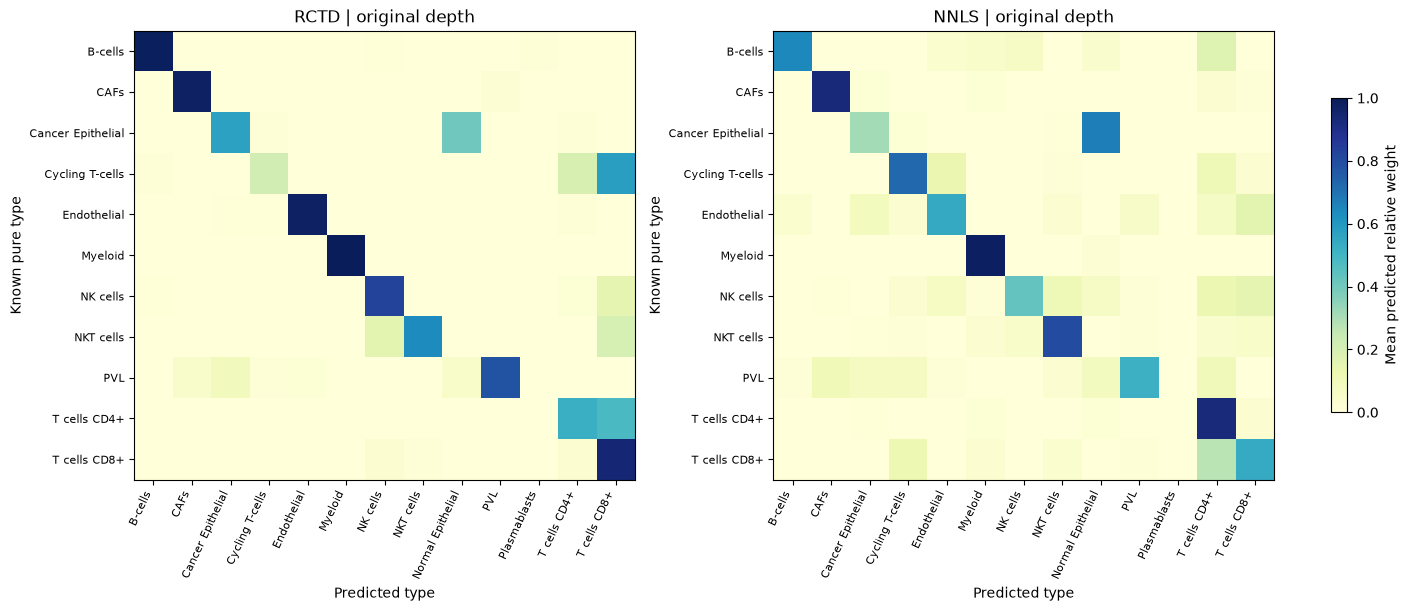

In [7]:
epithelial = ["Cancer Epithelial", "Normal Epithelial"]
epi_rows = []
for method, prediction in predictions.items():
    for depth in [1.0, 0.25]:
        ids = design.index[design.scenario.eq("factorial") & design.depth_fraction.eq(depth)]
        error = prediction.loc[ids, epithelial].sum(axis=1) - truth_rna.loc[ids, epithelial].sum(axis=1)
        epi_rows.append(dict(method=method, depth_fraction=depth, epithelial_total_mae_pp=error.abs().mean()*100))
epi_metrics = pd.DataFrame(epi_rows)
epi_metrics.to_csv(result_dir / "epithelial_total_diagnostic.csv", index=False)
display(epi_metrics)
pure_cancer_ids = design.index[design.scenario.eq("pure") & truth_cells["Cancer Epithelial"].eq(1)]
pure_cancer = pd.concat({method: frame.loc[pure_cancer_ids, epithelial] for method, frame in predictions.items()}, names=["method", "spot_id"])
pure_cancer.to_csv(result_dir / "pure_cancer_predictions.csv")
display(pure_cancer)
reference = ad.read_h5ad(input_dir / "reference_counts.h5ad", backed="r")
test = ad.read_h5ad(project_dir / "data/processed/Wu2021_ER_donor_qc_v1/CID4067_counts_before_qc.h5ad", backed="r")
obs = pd.concat([reference.obs, test.obs])
cancer_obs = obs[obs.celltype_major.eq("Cancer Epithelial")]
subtypes = pd.crosstab(cancer_obs["orig.ident"], cancer_obs.celltype_minor)
subtypes.to_csv(result_dir / "cancer_subtype_coverage.csv")
display(subtypes)
reference.file.close(); test.file.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
ids = design.index[design.scenario.eq("pure") & design.depth_fraction.eq(1)]
actual = truth_cells.loc[ids].idxmax(axis=1)
for ax, (method, prediction) in zip(axes, predictions.items()):
    table = prediction.loc[ids].groupby(actual).mean().reindex(columns=types)
    table.to_csv(result_dir / f"{method.lower()}_pure_type_confusion.csv")
    im = ax.imshow(table, vmin=0, vmax=1, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(types)), types, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(range(len(table)), table.index, fontsize=8)
    ax.set_xlabel("Predicted type")
    ax.set_ylabel("Known pure type")
    ax.set_title(f"{method} | original depth")
fig.colorbar(im, ax=axes, label="Mean predicted relative weight", shrink=0.7)
fig.savefig(result_dir / "pure_type_confusion.png", dpi=200)
fig.savefig(result_dir / "pure_type_confusion.pdf")
plt.show()


# 8. 保存本轮结果摘要

汇总原定指标及上皮类型分配的检查结果。


In [8]:
summary_lines = [
    "# 已知组成测试结果",
    "",
    "参考供者：CID4471、CID4535；测试供者：CID4067。",
    "244个基础混合，每个保留原深度和25%抽稀两个版本，共488个模拟spot。",
    "主要指标使用抽稀后实际捕获RNA的贡献份额；细胞数量份额另列。",
    "",
    "## 1. CAF与CD8的RNA份额误差",
    "",
]
for depth in [1.0, 0.25]:
    for target in ["CAFs", "T cells CD8+"]:
        for method in predictions:
            row = main[main.depth_fraction.eq(depth) & main.cell_type.eq(target) & main.method.eq(method)].iloc[0]
            summary_lines.append(
                f"- 深度{depth:g}，{target}，{method}：MAE={row.mae_pp:.3f}个百分点，"
                f"有目标细胞时MAE={row.present_mae_pp:.3f}，"
                f"缺失时预测均值={row.absent_mean_prediction_pct:.3f}%，"
                f"缺失时权重≥1%的比例={row.absent_ge1pct_fraction:.1%}。"
            )
summary_lines += [
    "",
    "## 2. 配方记录",
    "",
    "同一spot内细胞不重复，不同spot之间可以复用；同一基础混合的两个深度版本共享来源细胞。",
    "测试供者为一例IDC，参考为两例ILC；本次结果描述这套固定供者和模拟配方。",
    "RCTD执行原生预处理和平台校正，NNLS使用参考侧选择的2000个基因与每类平均表达。",
]
summary_lines += ["", "## 3. 癌上皮与正常上皮的分配", "",
    "测试供者没有正常上皮，但两种方法都分配了较高的正常上皮权重。纯癌上皮对照也出现同样的混淆。"]
for method in predictions:
    for depth in [1.0, 0.25]:
        subset = metrics[metrics.truth.eq("rna") & metrics.scenario.eq("factorial") & metrics.method.eq(method) & metrics.depth_fraction.eq(depth)]
        normal = subset[subset.cell_type.eq("Normal Epithelial")].iloc[0]
        cancer = subset[subset.cell_type.eq("Cancer Epithelial")].iloc[0]
        total = epi_metrics[epi_metrics.method.eq(method) & epi_metrics.depth_fraction.eq(depth)].iloc[0]
        summary_lines.append(f"- {method}，深度{depth:g}：正常上皮平均预测{normal.absent_mean_prediction_pct:.3f}%，癌上皮MAE={cancer.mae_pp:.3f}个百分点；两类相加后MAE={total.epithelial_total_mae_pp:.3f}个百分点。")
summary_lines += ["", "参考癌上皮中LumB为2025个、LumA为169个，测试癌上皮中LumA为1827个、LumB为401个。作者亚型组成差异可能影响类型分配，需要另外比较参考方案来检验。",
    "上皮两类相加是本轮新增的诊断指标，原定13类误差和原始预测均保留。",
    "本轮RCTD对CAF和CD8的RNA份额估计误差低于NNLS，但不能据此认为全部细胞类型均已通过准确性检查。",
    "原深度纯群对照中，RCTD对CAF和CD8均为5/5主导类型匹配，Cycling T为0/5；NNLS分别为5/5、3/5和5/5。",
    "下一步比较参考侧的上皮亚型覆盖和供者组成，保留本轮结果作为基线。CID4067已用于查看误差和选择后续方案，后续调整需再用未参与选方案的供者检验。"]
text = "\n".join(summary_lines)
(result_dir / "benchmark_summary.md").write_text(text, encoding="utf-8")
print(text)


# 已知组成测试结果

参考供者：CID4471、CID4535；测试供者：CID4067。
244个基础混合，每个保留原深度和25%抽稀两个版本，共488个模拟spot。
主要指标使用抽稀后实际捕获RNA的贡献份额；细胞数量份额另列。

## 1. CAF与CD8的RNA份额误差

- 深度1，CAFs，RCTD：MAE=3.601个百分点，有目标细胞时MAE=5.383，缺失时预测均值=0.036%，缺失时权重≥1%的比例=0.0%。
- 深度1，CAFs，NNLS：MAE=4.213个百分点，有目标细胞时MAE=5.742，缺失时预测均值=1.156%，缺失时权重≥1%的比例=30.2%。
- 深度1，T cells CD8+，RCTD：MAE=1.731个百分点，有目标细胞时MAE=2.536，缺失时预测均值=0.120%，缺失时权重≥1%的比例=4.8%。
- 深度1，T cells CD8+，NNLS：MAE=4.240个百分点，有目标细胞时MAE=6.328，缺失时预测均值=0.064%，缺失时权重≥1%的比例=1.6%。
- 深度0.25，CAFs，RCTD：MAE=3.469个百分点，有目标细胞时MAE=5.179，缺失时预测均值=0.050%，缺失时权重≥1%的比例=0.0%。
- 深度0.25，CAFs，NNLS：MAE=4.321个百分点，有目标细胞时MAE=5.802，缺失时预测均值=1.359%，缺失时权重≥1%的比例=30.2%。
- 深度0.25，T cells CD8+，RCTD：MAE=1.962个百分点，有目标细胞时MAE=2.886，缺失时预测均值=0.114%，缺失时权重≥1%的比例=6.3%。
- 深度0.25，T cells CD8+，NNLS：MAE=4.233个百分点，有目标细胞时MAE=6.297，缺失时预测均值=0.103%，缺失时权重≥1%的比例=1.6%。

## 2. 配方记录

同一spot内细胞不重复，不同spot之间可以复用；同一基础混合的两个深度版本共享来源细胞。
测试供者为一例IDC，参考为两例ILC；本次结果描述这套固定供者和模拟配方。
RCTD执行原生预处理和平台校正，NNLS使用参考侧选择的2000个基因与每类平均表达。

## 3. 癌上皮与正常上皮的分配

测试供者没有正常上皮，但两种方